In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Point to your running MLflow server
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("cumin-price-forecasting")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Setup complete ✅")

c:\Users\Akshita\anaconda3\envs\food-forecast\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/04/17 10:33:47 INFO mlflow.tracking.fluent: Experiment with name 'cumin-price-forecasting' does not exist. Creating a new experiment.


MLflow tracking URI: http://127.0.0.1:5000
Setup complete ✅


In [2]:
df = pd.read_csv('../data/processed/cumin_processed.csv', parse_dates=['date'])
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"States: {df['state'].nunique()}")
df.head()

Shape: (6045, 19)
Date range: 2020-01-01 00:00:00 → 2025-12-31 00:00:00
States: 10


,date,state,modal_price,arrivals,num_markets,year,month,quarter,day_of_week,day_of_year,is_harvest_season,is_lean_season,price_lag_7,price_lag_14,price_lag_30,arrivals_lag_7,price_roll_7,price_roll_30,arrivals_roll_7
0,2025-12-19,Assam,36000.0,2.5,1,2025,12,4,4,353,0,0,NaN,NaN,NaN,NaN,36000.0,36000.0,2.500
1,2025-12-20,Assam,36000.0,2.0,1,2025,12,4,5,354,0,0,NaN,NaN,NaN,NaN,36000.0,36000.0,2.250
2,2025-12-24,Assam,36600.0,3.0,1,2025,12,4,2,358,0,0,NaN,NaN,NaN,NaN,36200.0,36200.0,2.500
3,2025-12-25,Assam,36700.0,5.0,1,2025,12,4,3,359,0,0,NaN,NaN,NaN,NaN,36325.0,36325.0,3.125
4,2025-12-26,Assam,34700.0,4.0,1,2025,12,4,4,360,0,0,NaN,NaN,NaN,NaN,36000.0,36000.0,3.300


In [3]:
FEATURES = [
    'year', 'month', 'day_of_year', 'day_of_week',
    'is_harvest_season', 'is_lean_season',
    'arrivals', 'num_markets',
    'price_lag_7', 'price_lag_14', 'price_lag_30',
    'arrivals_lag_7',
    'price_roll_7', 'price_roll_30', 'arrivals_roll_7'
]
TARGET = 'modal_price'

# Temporal split — train on 2020-2024, test on 2025
train = df[df['year'] < 2025].dropna(subset=FEATURES)
test  = df[df['year'] == 2025].dropna(subset=FEATURES)

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train years: {train['year'].unique()}")
print(f"Test years:  {test['year'].unique()}")

Train: (4813, 15) | Test: (998, 15)
Train years: [2022 2023 2024 2020 2021]
Test years:  [2025]


In [4]:
def evaluate(y_true, y_pred, model_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{model_name:30s} → RMSE: {rmse:8.0f} | MAE: {mae:8.0f} | MAPE: {mape:.2f}%")
    return {"rmse": rmse, "mae": mae, "mape": mape}

In [5]:
with mlflow.start_run(run_name="LinearRegression_baseline"):
    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    metrics = evaluate(y_test, preds, "LinearRegression")
    
    # Log to MLflow
    mlflow.log_params({"model": "LinearRegression", "features": len(FEATURES)})
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(model, "model")
    
    print("Run logged to MLflow ✅")

2026/04/17 10:35:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LinearRegression               → RMSE:     1663 | MAE:      757 | MAPE: 4.95%


2026/04/17 10:35:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged to MLflow ✅
🏃 View run LinearRegression_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/4fba85bd7ebd4a9c9537230ecf1266d6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
with mlflow.start_run(run_name="XGBoost_default"):
    params = {
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42
    }
    model_xgb = XGBRegressor(**params)
    model_xgb.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)
    preds_xgb = model_xgb.predict(X_test)
    
    metrics_xgb = evaluate(y_test, preds_xgb, "XGBoost_default")
    
    # Log to MLflow
    mlflow.log_params(params)
    mlflow.log_metrics(metrics_xgb)
    mlflow.xgboost.log_model(model_xgb, "model")
    
    print("Run logged to MLflow")

2026/04/17 10:35:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost_default                → RMSE:     2060 | MAE:     1405 | MAPE: 8.53%
Run logged to MLflow ✅
🏃 View run XGBoost_default at: http://127.0.0.1:5000/#/experiments/1/runs/3512c6e7721041c69b0d273233cc8a20
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [10]:
with mlflow.start_run(run_name="XGBoost_tuned"):
    params_tuned = {
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.05,
        "subsample": 0.85,
        "colsample_bytree": 0.75,
        "min_child_weight": 5,
        "gamma": 0.1,
        "random_state": 42
    }
    model_tuned = XGBRegressor(**params_tuned)
    model_tuned.fit(X_train, y_train,
                    eval_set=[(X_test, y_test)],
                    verbose=False)
    preds_tuned = model_tuned.predict(X_test)
    
    metrics_tuned = evaluate(y_test, preds_tuned, "XGBoost_tuned")
    
    mlflow.log_params(params_tuned)
    mlflow.log_metrics(metrics_tuned)
    mlflow.xgboost.log_model(model_tuned, "model")
    

2026/04/17 10:39:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost_tuned                  → RMSE:     2003 | MAE:     1308 | MAPE: 7.87%
🏃 View run XGBoost_tuned at: http://127.0.0.1:5000/#/experiments/1/runs/bb082d2a433a4b3ea5f7b51fd689f991
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


                               → RMSE:     1663 | MAE:      757 | MAPE: 4.95%
                               → RMSE:     2060 | MAE:     1405 | MAPE: 8.53%
                               → RMSE:     2003 | MAE:     1308 | MAPE: 7.87%


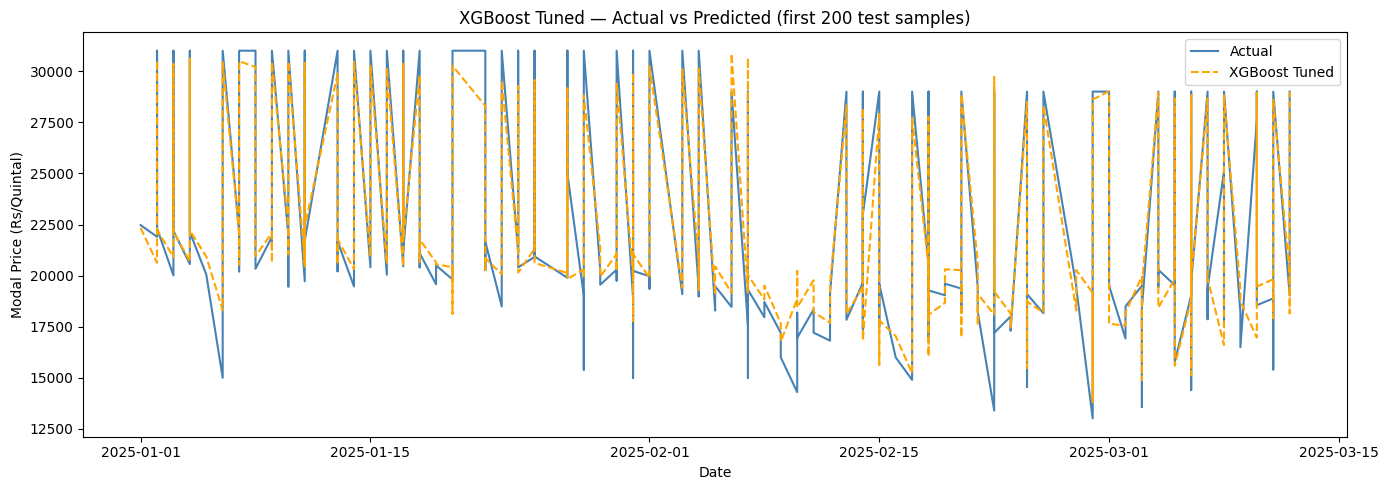

In [11]:
results = {
    "LinearRegression": evaluate(y_test, model.predict(X_test)),
    "XGBoost_default":  evaluate(y_test, preds_xgb),
    "XGBoost_tuned":    evaluate(y_test, preds_tuned),
}

# Plot predictions vs actual for best model
fig, ax = plt.subplots(figsize=(14, 5))
sample = test.sort_values('date').iloc[:200]
ax.plot(sample['date'], sample[TARGET], label='Actual', color='steelblue')
ax.plot(sample['date'], model_tuned.predict(sample[FEATURES]), 
        label='XGBoost Tuned', color='orange', linestyle='--')
ax.set_title('XGBoost Tuned — Actual vs Predicted (first 200 test samples)')
ax.set_xlabel('Date')
ax.set_ylabel('Modal Price (Rs/Quintal)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/prediction_plot.png', dpi=120)
plt.show()

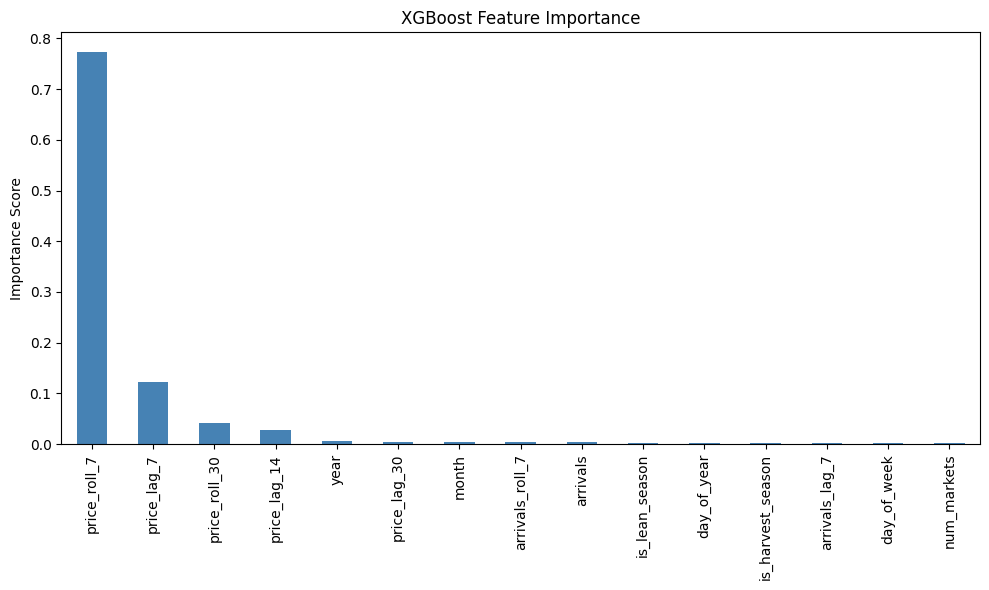


Top 5 features:
price_roll_7     0.773244
price_lag_7      0.122245
price_roll_30    0.041458
price_lag_14     0.027233
year             0.006702
dtype: float32


In [12]:
feat_imp = pd.Series(model_tuned.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance')
ax.set_ylabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=120)
plt.show()

print("\nTop 5 features:")
print(feat_imp.head())

In [13]:
# Find the best run and register it
client = mlflow.tracking.MlflowClient("http://127.0.0.1:5000")
experiment = client.get_experiment_by_name("cumin-price-forecasting")
runs = client.search_runs(experiment.experiment_id, order_by=["metrics.rmse ASC"])

best_run = runs[0]
best_run_id = best_run.info.run_id
print(f"Best run: {best_run.data.tags.get('mlflow.runName')}")
print(f"Run ID:   {best_run_id}")
print(f"RMSE:     {best_run.data.metrics['rmse']:.0f}")

# Register the model
model_uri = f"runs:/{best_run_id}/model"
registered = mlflow.register_model(model_uri, "cumin-forecaster")
print(f"\nModel registered as: cumin-forecaster v{registered.version} ✅")

Successfully registered model 'cumin-forecaster'.
2026/04/17 10:51:21 WARNING mlflow.tracking._model_registry.fluent: Run with id 4fba85bd7ebd4a9c9537230ecf1266d6 has no artifacts at artifact path 'model', registering model based on models:/m-9c0d0f3fa26c4dfaa51878f8dc20339f instead


Best run: LinearRegression_baseline
Run ID:   4fba85bd7ebd4a9c9537230ecf1266d6
RMSE:     1663


2026/04/17 10:51:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: cumin-forecaster, version 1



Model registered as: cumin-forecaster v1 ✅


Created version '1' of model 'cumin-forecaster'.


In [14]:
print("Phase 6 complete. Run the following in terminal:")
print("""
git add notebooks/03_experiments.ipynb src/train.py params.yaml
git commit -m "feat: Phase 6 - model training with MLflow, LR best RMSE 1663 MAPE 4.95%"
git push origin main
""")

Phase 6 complete. Run the following in terminal:

git add notebooks/03_experiments.ipynb src/train.py params.yaml
git commit -m "feat: Phase 6 - model training with MLflow, LR best RMSE 1663 MAPE 4.95%"
git push origin main

